# Tutorial 03: Toward Realistic Data

**Workshop: ML for Galactic Binary Search & Parameter Estimation**

---

## Project Goal

**Extend the signal model toward LISA realism** — understand what's needed to go from SlotFlow's toy sinusoids to actual GB signals.

This tutorial provides scaffolding for building more realistic data generators.

---

## Learning Outcomes (~30 min)

1. Understand the gap between toy and realistic GB signals
2. Implement frequency derivative (chirp) extension
3. Explore sky localization effects
4. Design a roadmap for full 8-parameter signals

---

In [1]:
# ================================================================
# Setup
# ================================================================
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
import torch
import torch.nn.functional as F

from src.dataset import MultiSinusoidDataset
from src.model import SlotFlow

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
# ================================================================
# Load Model for Comparison
# ================================================================

config_path = "../pretrained_model/test_clariden/model_config.pt"
ckpt_dir = "../pretrained_model/test_clariden/checkpoints"

config = torch.load(config_path, map_location="cpu")

ckpt_files = [f for f in os.listdir(ckpt_dir) if f.endswith(".ckpt")]
ckpt_path = os.path.join(ckpt_dir, sorted(ckpt_files)[-1])
ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = {k.replace("model.", "").replace("_orig_mod.", ""): v 
              for k, v in ckpt["state_dict"].items()}

model = SlotFlow(
    hidden_dim=config["hidden_dim"],
    max_slots=config["max_slots"],
    flow_depth=config.get("flow_depth", 8),
    use_noise_encoder=config.get("use_noise_encoder", False),
)
model.load_state_dict(state_dict, strict=True)
model.to(device).eval()

# Key parameters
FREQ_RANGE = config["freq_range"]
T_LONG = config["tEnd_long"]
T_SHORT = config["tEnd_short"]
N_LONG = config["num_samples_long"]
N_SHORT = config["num_samples_short"]

print(f"Model loaded. Will use for comparison.")

/var/folders/sr/n2fcp1f90810jp4b_lrryl700000gn/T/ipykernel_25724/2845044876.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  config = torch.load(config_path, map_location

Model loaded. Will use for comparison.


## 1. Current Signal Model vs Reality

Let's clearly lay out the gap between SlotFlow's model and real GBs.

In [3]:
# ================================================================
# Signal Model Comparison
# ================================================================

print("="*70)
print("SIGNAL MODEL COMPARISON")
print("="*70)
print("""
SLOTFLOW CURRENT MODEL:
────────────────────────
x(t) = Σₖ Aₖ sin(2πfₖt + φₖ) + ε(t)

Parameters per source: 3
  • A  : amplitude
  • φ  : initial phase  
  • f  : frequency (constant)

REAL LISA GB MODEL:
────────────────────
h(t) = A(t) × [F₊(t)h₊(t) + F×(t)h×(t)] + n(t)

where:
  h₊(t) = (1+cos²ι)/2 × cos(Φ(t))
  h×(t) = cos(ι) × sin(Φ(t))
  Φ(t) = 2π(f₀t + ½ḟt²) + φ₀
  F₊, F× = antenna pattern functions(λ, β, ψ, t)
  A(t) = amplitude modulation from orbital motion

Parameters per source: 8
  • f₀ : GW frequency at reference time
  • ḟ  : frequency derivative (chirp rate)
  • A  : intrinsic amplitude (∝ M_c^{5/3} f^{2/3} / D)
  • ι  : inclination angle
  • ψ  : polarization angle
  • φ₀ : initial GW phase
  • λ  : ecliptic longitude
  • β  : ecliptic latitude

ADDITIONAL EFFECTS:
  • TDI combinations (X, Y, Z or A, E, T channels)
  • Annual Doppler modulation from LISA orbit
  • Colored noise (LISA sensitivity curve)
  • Confusion foreground from unresolved GBs
""")

SIGNAL MODEL COMPARISON

SLOTFLOW CURRENT MODEL:
────────────────────────
x(t) = Σₖ Aₖ sin(2πfₖt + φₖ) + ε(t)

Parameters per source: 3
  • A  : amplitude
  • φ  : initial phase  
  • f  : frequency (constant)

REAL LISA GB MODEL:
────────────────────
h(t) = A(t) × [F₊(t)h₊(t) + F×(t)h×(t)] + n(t)

where:
  h₊(t) = (1+cos²ι)/2 × cos(Φ(t))
  h×(t) = cos(ι) × sin(Φ(t))
  Φ(t) = 2π(f₀t + ½ḟt²) + φ₀
  F₊, F× = antenna pattern functions(λ, β, ψ, t)
  A(t) = amplitude modulation from orbital motion

Parameters per source: 8
  • f₀ : GW frequency at reference time
  • ḟ  : frequency derivative (chirp rate)
  • A  : intrinsic amplitude (∝ M_c^{5/3} f^{2/3} / D)
  • ι  : inclination angle
  • ψ  : polarization angle
  • φ₀ : initial GW phase
  • λ  : ecliptic longitude
  • β  : ecliptic latitude

ADDITIONAL EFFECTS:
  • TDI combinations (X, Y, Z or A, E, T channels)
  • Annual Doppler modulation from LISA orbit
  • Colored noise (LISA sensitivity curve)
  • Confusion foreground from unresolved 

## 2. Extension 1: Adding Frequency Derivative (Chirp)

The simplest extension: let frequency evolve as f(t) = f₀ + ḟt

In [4]:
# ================================================================
# Chirping Signal Generator
# ================================================================

class ChirpingSignalGenerator:
    """
    Generate sinusoidal signals with frequency evolution (chirp).
    
    Signal model:
        x(t) = Σₖ Aₖ sin(2π(fₖt + ½ḟₖt²) + φₖ) + noise
    
    Parameters per source: 4
        - A: amplitude
        - φ: initial phase
        - f: initial frequency
        - ḟ: frequency derivative
    """
    
    def __init__(self, 
                 T_long=300, N_long=3000,
                 T_short=10, N_short=5120,
                 freq_range=(2.5, 3.0),
                 amp_range=(0.5, 1.5),
                 fdot_range=(-1e-4, 1e-4),  # Hz/s
                 noise_std_range=(0, 1.5)):
        
        self.T_long = T_long
        self.N_long = N_long
        self.T_short = T_short
        self.N_short = N_short
        self.freq_range = freq_range
        self.amp_range = amp_range
        self.fdot_range = fdot_range
        self.noise_std_range = noise_std_range
        
        # Time arrays
        self.t_long = torch.linspace(0, T_long, N_long)
        self.t_short = torch.linspace(0, T_short, N_short)
    
    def generate(self, K, min_freq_sep=0.01, seed=None):
        """
        Generate a signal with K chirping sources.
        
        Returns
        -------
        x_long, x_short : tensors
            Signal streams
        params : tensor (K, 4)
            [A, phi, f, fdot] for each source
        noise_std : float
            Noise level used
        """
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)
        
        # Sample frequencies with minimum separation
        freqs = []
        attempts = 0
        while len(freqs) < K and attempts < 100:
            f_try = np.random.uniform(*self.freq_range)
            if all(abs(f_try - f) >= min_freq_sep for f in freqs):
                freqs.append(f_try)
            attempts += 1
        K = len(freqs)  # May be less if couldn't fit all
        
        # Sample other parameters
        amps = np.random.uniform(*self.amp_range, K)
        phases = np.random.uniform(0, 2*np.pi, K)
        fdots = np.random.uniform(*self.fdot_range, K)
        noise_std = np.random.uniform(*self.noise_std_range)
        
        # Generate signals
        x_long = torch.zeros_like(self.t_long)
        x_short = torch.zeros_like(self.t_short)
        
        for i in range(K):
            # Phase: Φ(t) = 2π(f₀t + ½ḟt²) + φ₀
            phase_long = 2*np.pi*(freqs[i]*self.t_long + 0.5*fdots[i]*self.t_long**2) + phases[i]
            phase_short = 2*np.pi*(freqs[i]*self.t_short + 0.5*fdots[i]*self.t_short**2) + phases[i]
            
            x_long += amps[i] * torch.sin(phase_long)
            x_short += amps[i] * torch.sin(phase_short)
        
        # Add noise
        x_long += torch.randn_like(self.t_long) * noise_std
        x_short += torch.randn_like(self.t_short) * noise_std
        
        # Pack parameters
        params = torch.tensor(np.stack([amps, phases, freqs, fdots], axis=1)).float()
        
        return x_long.float(), x_short.float(), params, noise_std

# Create generator
chirp_gen = ChirpingSignalGenerator(
    T_long=T_LONG, N_long=N_LONG,
    T_short=T_SHORT, N_short=N_SHORT,
    freq_range=FREQ_RANGE,
)

print("ChirpingSignalGenerator created!")
print(f"  Frequency derivative range: {chirp_gen.fdot_range} Hz/s")
print(f"  Max frequency change over T_long: {chirp_gen.fdot_range[1] * T_LONG:.4f} Hz")

ChirpingSignalGenerator created!
  Frequency derivative range: (-0.0001, 0.0001) Hz/s
  Max frequency change over T_long: 0.0300 Hz


In [5]:
# ================================================================
# Visualize Chirping vs Non-Chirping Signals
# ================================================================

# Generate example with noticeable chirp
chirp_gen_strong = ChirpingSignalGenerator(
    T_long=T_LONG, N_long=N_LONG,
    T_short=T_SHORT, N_short=N_SHORT,
    freq_range=FREQ_RANGE,
    fdot_range=(5e-4, 1e-3),  # Strong chirp for visualization
)

x_chirp_long, x_chirp_short, params_chirp, _ = chirp_gen_strong.generate(K=1, seed=42)

# Generate non-chirping for comparison
A, phi, f0, fdot = params_chirp[0].tolist()
t_long = chirp_gen.t_long
x_nochirp_long = A * torch.sin(2*np.pi*f0*t_long + phi)

print(f"Chirping signal: f₀={f0:.4f} Hz, ḟ={fdot:.6f} Hz/s")
print(f"Frequency at t=0: {f0:.4f} Hz")
print(f"Frequency at t={T_LONG}s: {f0 + fdot*T_LONG:.4f} Hz")
print(f"Total frequency change: {fdot*T_LONG*1000:.2f} mHz")

Chirping signal: f₀=2.6873 Hz, ḟ=0.000799 Hz/s
Frequency at t=0: 2.6873 Hz
Frequency at t=300s: 2.9271 Hz
Total frequency change: 239.80 mHz


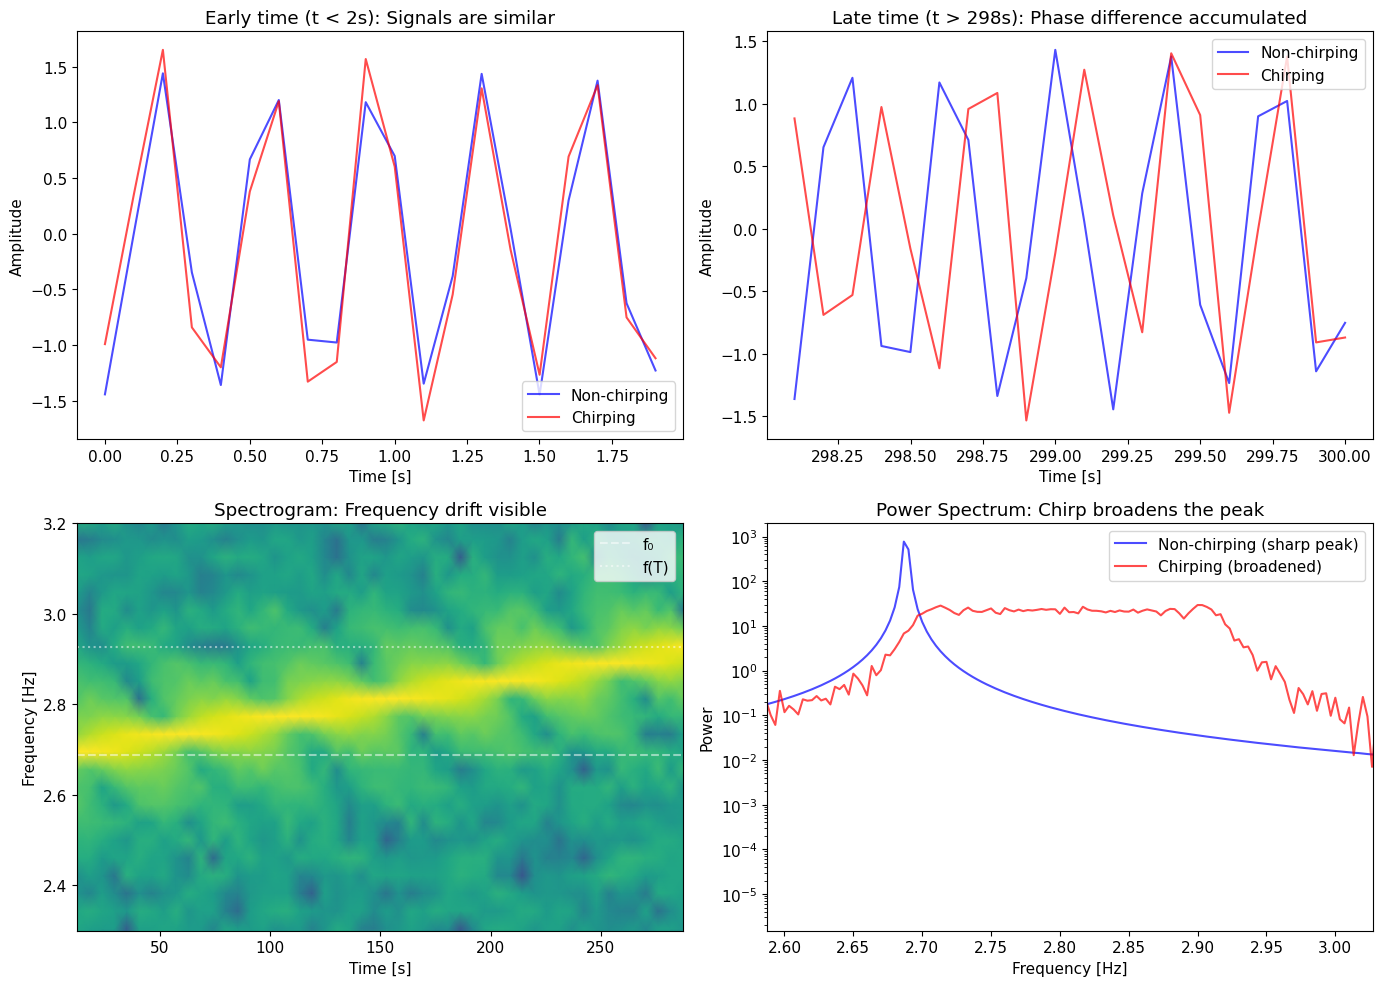

In [6]:
# ================================================================
# Plot Chirp Effect
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time domain (early)
ax = axes[0, 0]
t_zoom = t_long < 2
ax.plot(t_long[t_zoom], x_nochirp_long[t_zoom], 'b-', alpha=0.7, label='Non-chirping')
ax.plot(t_long[t_zoom], x_chirp_long[t_zoom], 'r-', alpha=0.7, label='Chirping')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Early time (t < 2s): Signals are similar')
ax.legend()

# 2. Time domain (late)
ax = axes[0, 1]
t_late = (t_long > T_LONG - 2)
ax.plot(t_long[t_late], x_nochirp_long[t_late], 'b-', alpha=0.7, label='Non-chirping')
ax.plot(t_long[t_late], x_chirp_long[t_late], 'r-', alpha=0.7, label='Chirping')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude')
ax.set_title(f'Late time (t > {T_LONG-2}s): Phase difference accumulated')
ax.legend()

# 3. Spectrogram of chirping signal
ax = axes[1, 0]
from scipy import signal as scipy_signal
f_spec, t_spec, Sxx = scipy_signal.spectrogram(
    x_chirp_long.numpy(), fs=N_LONG/T_LONG, nperseg=256, noverlap=200
)
ax.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
ax.set_ylim(FREQ_RANGE[0]-0.2, FREQ_RANGE[1]+0.2)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Frequency [Hz]')
ax.set_title('Spectrogram: Frequency drift visible')
ax.axhline(f0, color='white', ls='--', alpha=0.5, label='f₀')
ax.axhline(f0 + fdot*T_LONG, color='white', ls=':', alpha=0.5, label='f(T)')
ax.legend()

# 4. Power spectrum comparison
ax = axes[1, 1]
freqs = np.fft.rfftfreq(len(x_chirp_long), d=T_LONG/len(x_chirp_long))
power_chirp = np.abs(np.fft.rfft(x_chirp_long.numpy()))**2 / len(x_chirp_long)
power_nochirp = np.abs(np.fft.rfft(x_nochirp_long.numpy()))**2 / len(x_nochirp_long)

ax.semilogy(freqs, power_nochirp, 'b-', alpha=0.7, label='Non-chirping (sharp peak)')
ax.semilogy(freqs, power_chirp, 'r-', alpha=0.7, label='Chirping (broadened)')
ax.set_xlim(f0 - 0.1, f0 + fdot*T_LONG + 0.1)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power')
ax.set_title('Power Spectrum: Chirp broadens the peak')
ax.legend()

plt.tight_layout()
plt.show()

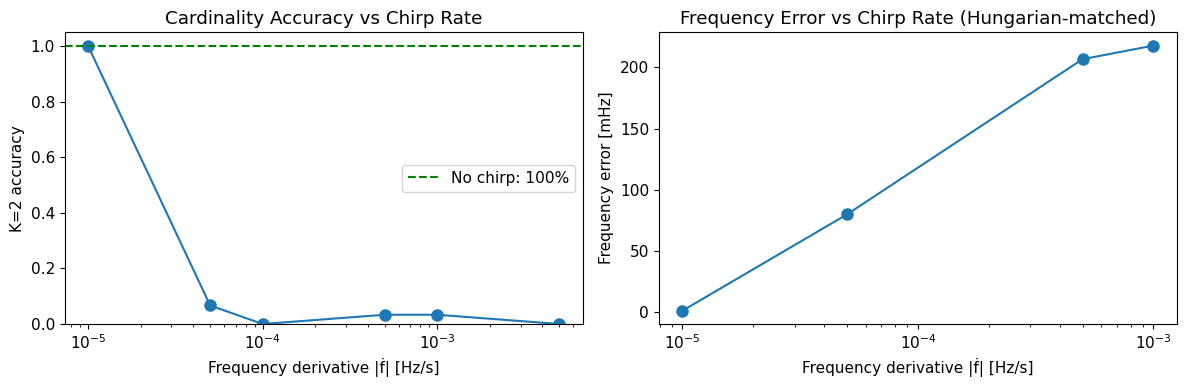


Note: SlotFlow was trained on non-chirping signals.
Performance degrades as chirp rate increases (model mismatch).


In [7]:
# ================================================================
# Test SlotFlow on Chirping Signals (with Hungarian Matching)
# ================================================================

def hungarian_match(model, context, true_params, K_pred, freq_center):
    """
    Compute Hungarian matching between slots and true sources.
    Uses flow log-prob as cost (consistent with training).
    
    Note: For chirping signals, we use f0 (initial frequency) for matching.
    """
    true_k = len(true_params)
    
    # Convert true params to flow representation (ensure float32)
    if torch.is_tensor(true_params):
        tp = true_params.float()
    else:
        tp = torch.tensor(true_params, dtype=torch.float32)
    
    # true_params for chirping: [A, phi, f0, fdot]
    # We only use A, phi, f0 for matching (ignore fdot)
    amp = tp[:, 0]
    phi = tp[:, 1]
    freq = tp[:, 2]  # Initial frequency
    
    true_params_4d = torch.stack(
        [amp, torch.cos(phi), torch.sin(phi), freq], dim=1
    ).to(device)
    
    # Apply normalization (same as training)
    gt_weighted = true_params_4d.clone()
    gt_weighted[:, 1:3] *= 2
    gt_weighted[:, 3] -= freq_center
    gt_weighted[:, 3] *= 3
    
    # Compute cost matrix
    ctx_exp = context.unsqueeze(0).expand(true_k, -1, -1)
    gt_exp = gt_weighted.unsqueeze(1).expand(-1, K_pred, -1)
    all_ctx = ctx_exp.reshape(-1, context.shape[-1])
    all_gt = gt_exp.reshape(-1, gt_weighted.shape[-1])
    
    logp = model.flow.log_prob(all_gt, context=all_ctx)
    cost = -logp.view(true_k, K_pred).detach().cpu().numpy()
    
    return linear_sum_assignment(cost)


@torch.no_grad()
def test_chirp_robustness(model, chirp_gen, fdot_values, n_trials=20):
    """
    Test how SlotFlow handles chirping signals (mismatch with training).
    Uses Hungarian matching for proper slot-to-source alignment.
    """
    results = {'fdot': [], 'k_accuracy': [], 'freq_error': []}
    freq_center = (FREQ_RANGE[0] + FREQ_RANGE[1]) / 2
    
    for fdot in fdot_values:
        # Modify generator
        test_gen = ChirpingSignalGenerator(
            T_long=T_LONG, N_long=N_LONG,
            T_short=T_SHORT, N_short=N_SHORT,
            freq_range=FREQ_RANGE,
            fdot_range=(fdot, fdot),  # Fixed fdot
        )
        
        k_correct = 0
        freq_errors = []
        
        for trial in range(n_trials):
            x_long, x_short, params, _ = test_gen.generate(K=2, seed=trial)
            
            x_l = x_long.unsqueeze(0).to(device)
            x_s = x_short.unsqueeze(0).to(device)
            output = model(x_l, x_s)
            
            k_pred = output['K_pred'].item()
            if k_pred == 2:
                k_correct += 1
                
                context = output['context']
                
                # Hungarian matching (using initial frequency f0)
                row_ind, col_ind = hungarian_match(
                    model, context, params, k_pred, freq_center
                )
                
                # Compute frequency error for matched pairs
                errors = []
                for true_idx, slot_idx in zip(row_ind, col_ind):
                    samples = model.flow.sample(100, context=context[slot_idx:slot_idx+1])
                    f_pred = (samples[..., 3].mean().item() / 3.0) + freq_center
                    f_true = params[true_idx, 2].item()  # Initial frequency
                    errors.append(abs(f_pred - f_true))
                
                freq_errors.append(np.mean(errors))
        
        results['fdot'].append(fdot)
        results['k_accuracy'].append(k_correct / n_trials)
        results['freq_error'].append(np.mean(freq_errors) if freq_errors else np.nan)
    
    return {k: np.array(v) for k, v in results.items()}

# Test with increasing chirp rates
fdot_values = np.array([0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3])
chirp_results = test_chirp_robustness(model, chirp_gen, fdot_values, n_trials=30)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.semilogx(chirp_results['fdot'][1:], chirp_results['k_accuracy'][1:], 'o-', markersize=8)
ax.axhline(chirp_results['k_accuracy'][0], color='green', ls='--', label=f'No chirp: {chirp_results["k_accuracy"][0]:.0%}')
ax.set_xlabel('Frequency derivative |ḟ| [Hz/s]')
ax.set_ylabel('K=2 accuracy')
ax.set_title('Cardinality Accuracy vs Chirp Rate')
ax.legend()
ax.set_ylim(0, 1.05)

ax = axes[1]
valid = ~np.isnan(chirp_results['freq_error'])
ax.semilogx(chirp_results['fdot'][valid][1:], chirp_results['freq_error'][valid][1:]*1000, 'o-', markersize=8)
ax.set_xlabel('Frequency derivative |ḟ| [Hz/s]')
ax.set_ylabel('Frequency error [mHz]')
ax.set_title('Frequency Error vs Chirp Rate (Hungarian-matched)')

plt.tight_layout()
plt.show()

print("\nNote: SlotFlow was trained on non-chirping signals.")
print("Performance degrades as chirp rate increases (model mismatch).")

## 3. Extension 2: Sky Localization Effects

For real GBs, the signal is modulated by LISA's orbital motion. Let's visualize this.

In [8]:
# ================================================================
# LISA Orbital Modulation (Simplified)
# ================================================================

def lisa_antenna_pattern(theta, phi, psi, t, T_year=365.25*24*3600):
    """
    Simplified LISA antenna pattern functions.
    
    Parameters
    ----------
    theta : float
        Polar angle (co-latitude) in radians
    phi : float
        Azimuthal angle (longitude) in radians
    psi : float
        Polarization angle in radians
    t : array
        Time in seconds
    T_year : float
        Orbital period in seconds
    
    Returns
    -------
    F_plus, F_cross : arrays
        Antenna pattern functions
    """
    # LISA orbital phase
    phi_orb = 2 * np.pi * t / T_year
    
    # Simplified antenna pattern (ignoring many details)
    # Real pattern depends on arm geometry and TDI combination
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    # Time-dependent modulation from orbital motion
    F_plus = 0.5 * (1 + cos_theta**2) * np.cos(2*(phi - phi_orb)) * np.cos(2*psi) \
           - cos_theta * np.sin(2*(phi - phi_orb)) * np.sin(2*psi)
    
    F_cross = 0.5 * (1 + cos_theta**2) * np.cos(2*(phi - phi_orb)) * np.sin(2*psi) \
            + cos_theta * np.sin(2*(phi - phi_orb)) * np.cos(2*psi)
    
    return F_plus, F_cross

def generate_sky_modulated_signal(t, f, A, phi0, theta_src, phi_src, psi, iota):
    """
    Generate a GB signal with sky-dependent modulation.
    
    Parameters
    ----------
    t : array
        Time in seconds
    f : float
        GW frequency in Hz
    A : float
        Intrinsic amplitude
    phi0 : float
        Initial phase
    theta_src, phi_src : float
        Source sky position (polar, azimuthal) in radians
    psi : float
        Polarization angle
    iota : float
        Inclination angle
    
    Returns
    -------
    h : array
        Strain signal
    """
    # Polarization amplitudes
    A_plus = A * (1 + np.cos(iota)**2) / 2
    A_cross = A * np.cos(iota)
    
    # GW polarizations
    phase = 2 * np.pi * f * t + phi0
    h_plus = A_plus * np.cos(phase)
    h_cross = A_cross * np.sin(phase)
    
    # Antenna patterns
    F_plus, F_cross = lisa_antenna_pattern(theta_src, phi_src, psi, t)
    
    # Combined signal
    h = F_plus * h_plus + F_cross * h_cross
    
    return h, F_plus, F_cross

print("Sky modulation functions defined.")

Sky modulation functions defined.


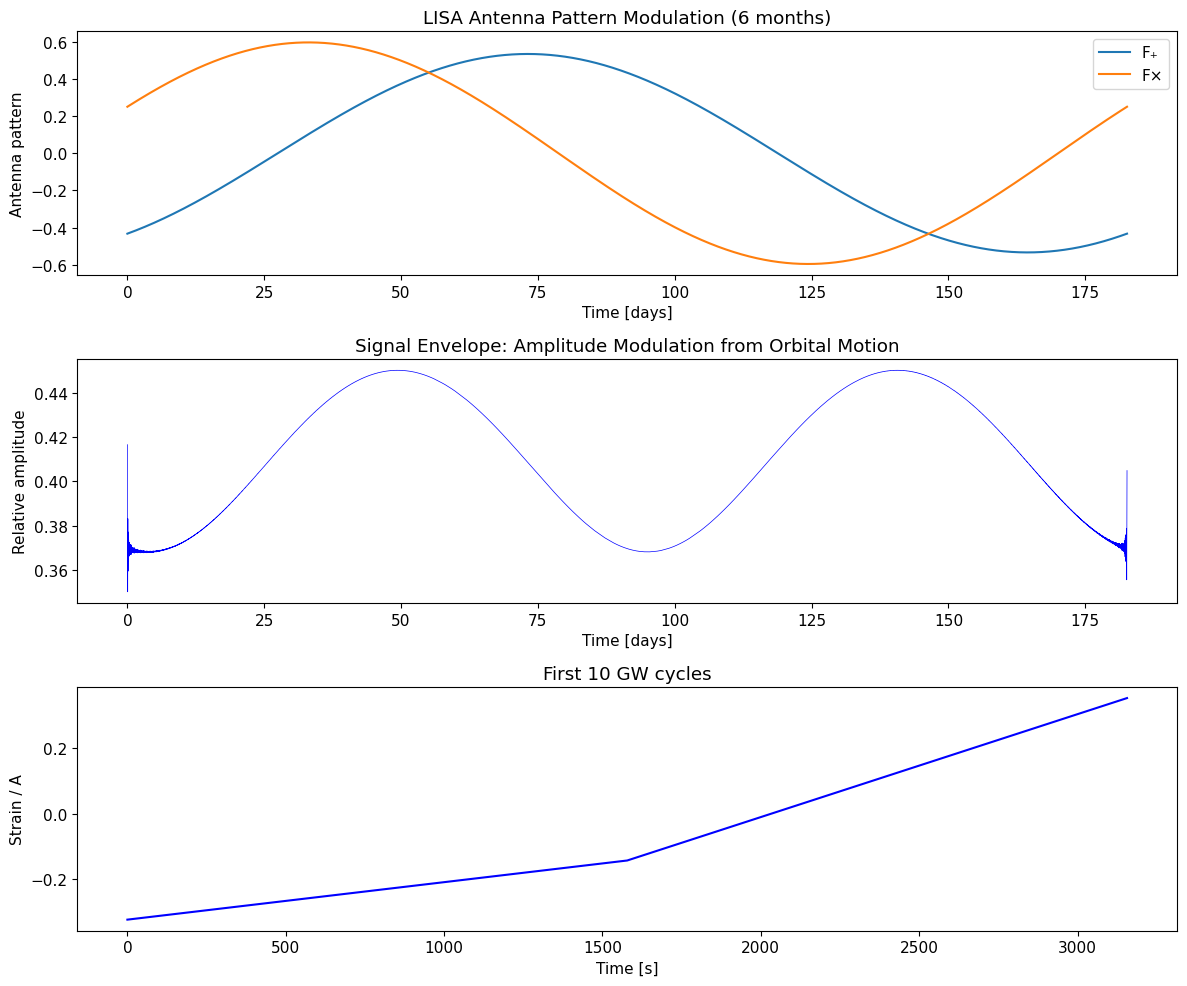


Key insight: Sky localization comes from the annual modulation pattern.
Different sky positions produce different modulation signatures.


In [9]:
# ================================================================
# Visualize Sky Modulation Effect
# ================================================================

# Generate 1 year of data (scaled)
T_year = 365.25 * 24 * 3600  # seconds
T_obs = 0.5 * T_year  # 6 months
N_obs = 10000
t_obs = np.linspace(0, T_obs, N_obs)

# Source parameters
f_gw = 3e-3  # 3 mHz (typical GB)
A = 1e-22
phi0 = 0
theta_src = np.pi/3  # 60 deg from pole
phi_src = np.pi/4    # 45 deg longitude
psi = np.pi/6
iota = np.pi/4

# Generate signal
h, F_plus, F_cross = generate_sky_modulated_signal(
    t_obs, f_gw, A, phi0, theta_src, phi_src, psi, iota
)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. Antenna patterns over time
ax = axes[0]
ax.plot(t_obs / (24*3600), F_plus, label='F₊')
ax.plot(t_obs / (24*3600), F_cross, label='F×')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Antenna pattern')
ax.set_title('LISA Antenna Pattern Modulation (6 months)')
ax.legend()

# 2. Signal envelope
ax = axes[1]
# Compute envelope using Hilbert transform
from scipy.signal import hilbert
envelope = np.abs(hilbert(h))
ax.plot(t_obs / (24*3600), envelope / A, 'b-', linewidth=0.5)
ax.set_xlabel('Time [days]')
ax.set_ylabel('Relative amplitude')
ax.set_title('Signal Envelope: Amplitude Modulation from Orbital Motion')

# 3. Zoom on a few cycles
ax = axes[2]
# Show ~10 GW cycles
n_cycles = 10
t_zoom = t_obs < n_cycles / f_gw
ax.plot(t_obs[t_zoom], h[t_zoom] / A, 'b-')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Strain / A')
ax.set_title(f'First {n_cycles} GW cycles')

plt.tight_layout()
plt.show()

print("\nKey insight: Sky localization comes from the annual modulation pattern.")
print("Different sky positions produce different modulation signatures.")

## 4. Roadmap to Full 8-Parameter Signals

Here's a step-by-step roadmap for extending toward realistic GB signals:

In [10]:
# ================================================================
# Extension Roadmap
# ================================================================

print("="*70)
print("ROADMAP: TOY MODEL → REALISTIC GB SIGNALS")
print("="*70)
print("""
LEVEL 0 (Current SlotFlow):
─────────────────────────────
• Parameters: (A, φ, f) = 3D
• Signal: x(t) = Σ A sin(2πft + φ)
• Complexity: ★☆☆☆☆

LEVEL 1 (Add chirp):
─────────────────────
• Parameters: (A, φ, f, ḟ) = 4D
• Signal: x(t) = Σ A sin(2π(ft + ½ḟt²) + φ)
• Changes needed:
  - Modify dataset generator ✓ (done above)
  - Extend flow output dimension (4 → 5)
  - Retrain model
• Complexity: ★★☆☆☆

LEVEL 2 (Add polarization/inclination):
─────────────────────────────────────────
• Parameters: (A, φ, f, ḟ, ι, ψ) = 6D
• Signal: h = F₊h₊ + F×h× (two polarizations)
• Changes needed:
  - Generate both polarizations
  - Handle ι-A degeneracy in training
  - Extend flow dimension
• Complexity: ★★★☆☆

LEVEL 3 (Add sky location):
────────────────────────────
• Parameters: (A, φ, f, ḟ, ι, ψ, λ, β) = 8D
• Signal: Full antenna pattern, Doppler modulation
• Changes needed:
  - Implement LISA response
  - Long observation times (months to years)
  - Different encoder architecture?
• Complexity: ★★★★☆

LEVEL 4 (TDI + realistic noise):
──────────────────────────────────
• Multiple TDI channels (A, E, T or X, Y, Z)
• LISA noise curve (colored noise)
• Confusion foreground
• Changes needed:
  - TDI response functions
  - Noise modeling
  - Multi-channel encoder
• Complexity: ★★★★★
""")

ROADMAP: TOY MODEL → REALISTIC GB SIGNALS

LEVEL 0 (Current SlotFlow):
─────────────────────────────
• Parameters: (A, φ, f) = 3D
• Signal: x(t) = Σ A sin(2πft + φ)
• Complexity: ★☆☆☆☆

LEVEL 1 (Add chirp):
─────────────────────
• Parameters: (A, φ, f, ḟ) = 4D
• Signal: x(t) = Σ A sin(2π(ft + ½ḟt²) + φ)
• Changes needed:
  - Modify dataset generator ✓ (done above)
  - Extend flow output dimension (4 → 5)
  - Retrain model
• Complexity: ★★☆☆☆

LEVEL 2 (Add polarization/inclination):
─────────────────────────────────────────
• Parameters: (A, φ, f, ḟ, ι, ψ) = 6D
• Signal: h = F₊h₊ + F×h× (two polarizations)
• Changes needed:
  - Generate both polarizations
  - Handle ι-A degeneracy in training
  - Extend flow dimension
• Complexity: ★★★☆☆

LEVEL 3 (Add sky location):
────────────────────────────
• Parameters: (A, φ, f, ḟ, ι, ψ, λ, β) = 8D
• Signal: Full antenna pattern, Doppler modulation
• Changes needed:
  - Implement LISA response
  - Long observation times (months to years)
  - Diffe

In [11]:
# ================================================================
# Scaffold: Extended Dataset Class
# ================================================================

class ExtendedGBDataset:
    """
    Scaffold for extended GB dataset with more parameters.
    
    This is a template for workshop participants to extend.
    """
    
    def __init__(self, 
                 level=1,  # 1=chirp, 2=+polarization, 3=+sky
                 T_obs=300,
                 N_samples=3000,
                 freq_range=(2.5, 3.0),
                 max_K=10):
        
        self.level = level
        self.T_obs = T_obs
        self.N_samples = N_samples
        self.freq_range = freq_range
        self.max_K = max_K
        
        self.t = np.linspace(0, T_obs, N_samples)
        
        # Parameter dimensions by level
        self.param_dims = {
            0: 3,  # A, φ, f
            1: 4,  # + ḟ
            2: 6,  # + ι, ψ
            3: 8,  # + λ, β
        }
        
        print(f"ExtendedGBDataset initialized at level {level}")
        print(f"  Parameters per source: {self.param_dims[level]}")
    
    def generate_signal(self, params):
        """
        Generate signal for given parameters.
        
        TODO: Implement for each level.
        """
        if self.level == 0:
            return self._generate_level0(params)
        elif self.level == 1:
            return self._generate_level1(params)
        elif self.level == 2:
            return self._generate_level2(params)
        elif self.level == 3:
            return self._generate_level3(params)
        else:
            raise ValueError(f"Unknown level: {self.level}")
    
    def _generate_level0(self, params):
        """Level 0: Simple sinusoids (current SlotFlow)."""
        A, phi, f = params
        return A * np.sin(2*np.pi*f*self.t + phi)
    
    def _generate_level1(self, params):
        """Level 1: Add chirp."""
        A, phi, f, fdot = params
        phase = 2*np.pi*(f*self.t + 0.5*fdot*self.t**2) + phi
        return A * np.sin(phase)
    
    def _generate_level2(self, params):
        """Level 2: Add polarization/inclination."""
        A, phi, f, fdot, iota, psi = params
        
        # TODO: Implement two-polarization signal
        # h_plus = ...
        # h_cross = ...
        # return F_plus * h_plus + F_cross * h_cross
        
        raise NotImplementedError("Level 2 not yet implemented")
    
    def _generate_level3(self, params):
        """Level 3: Full 8-parameter signal."""
        A, phi, f, fdot, iota, psi, lam, beta = params
        
        # TODO: Implement full LISA response
        # - Convert (λ, β) to antenna pattern
        # - Include Doppler modulation
        
        raise NotImplementedError("Level 3 not yet implemented")

# Example usage
dataset_l1 = ExtendedGBDataset(level=1)

ExtendedGBDataset initialized at level 1
  Parameters per source: 4


---

## Project Extensions

**Ideas for workshop projects:**

1. **Complete Level 1**: Implement and test chirping signal dataset

2. **Implement Level 2**: Add polarization and inclination

3. **Interface with existing tools**: Use `lisatools` or `GLASS` signal generators

4. **Colored noise**: Add LISA sensitivity curve to noise model

5. **Confusion foreground**: Model the unresolved GB background

---

In [12]:
# ================================================================
# YOUR TURN: Extend the Dataset
# ================================================================

# TODO: Pick one extension and implement it
#
# Option 1: Complete the chirping dataset
#   - Create proper training/test splits
#   - Integrate with SlotFlow training pipeline
#
# Option 2: Add colored noise
#   - Implement LISA noise curve
#   - Generate noise with correct PSD
#
# Option 3: Interface with external tools
#   - pip install lisatools
#   - Use their signal generators
#   - Wrap in SlotFlow-compatible format